# 06 – Modelagem Preditiva (ML)
**Objetivo:** Treinar, otimizar e avaliar modelos de classificação para prever o desfecho de óbito hospitalar (indicador_obito) em pacientes internados por IAM. Faremos a comparação entre modelos lineares e baseados em árvores, seguidos de análise de interpretabilidade.

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import sys
import os

# Configurações gráficas estritas conforme normas da instituição
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "DejaVu Sans", "Helvetica"],
    "font.size": 11,
    "text.color": "black",
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.linewidth": 1.5,
    "axes.facecolor": "none",
    "figure.facecolor": "none",
    "axes.grid": False,
    "xtick.color": "black",
    "ytick.color": "black",
    "xtick.major.width": 1.5,
    "ytick.major.width": 1.5,
    "axes.spines.top": False,
    "axes.spines.right": False
})
sns.set_style("white")
def enforce_tcc_style():
    import matplotlib.pyplot as plt
    import seaborn as sns
    try:
        plt.grid(False)
        sns.despine(top=True, right=True, left=False, bottom=False)
        for ax_ in plt.gcf().axes:
            ax_.grid(False)
            ax_.spines['top'].set_visible(False)
            ax_.spines['right'].set_visible(False)
            ax_.spines['bottom'].set_linewidth(1.5)
            ax_.spines['bottom'].set_color('black')
            ax_.spines['left'].set_linewidth(1.5)
            ax_.spines['left'].set_color('black')
            ax_.tick_params(colors='black', width=1.5)
            if ax_.get_title(): ax_.set_title('')
    except Exception: pass


In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device configurado para processamento: {DEVICE}")

# Garante que a raiz do projeto está no sys.path para importar src/
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print(f"Raiz do projeto: {ROOT}")


Device configurado para processamento: cuda
Raiz do projeto: /home/carolina/Documents/TCC Documentos/TCC


In [3]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Preprocessing & Metrics
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, RocCurveDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Interpretability
import shap

import warnings
warnings.filterwarnings('ignore')

FIG_PATH = Path('../reports/figures')
FIG_PATH.mkdir(parents=True, exist_ok=True)

# sns.set_theme(style='whitegrid') # SOBRESCRITO PELO TCC


/home/carolina/miniconda3/envs/iam/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregamento e Pré-processamento

Carregaremos a base reduzida (saída do notebook 05). Aplicamos One-Hot Encoding nas variáveis categóricas e realizamos o **split temporal**: internações de 2015 a 2022 compõem o **treino**, e internações de 2023 a 2025 compõem o **teste** — garantindo que o modelo nunca veja dados futuros durante o aprendizado.

In [4]:
DATA_PATH = Path('../data/processed/base_modelagem_reduzida.csv')
df = pd.read_csv(DATA_PATH, low_memory=False)

df['indicador_obito'] = df['indicador_obito'].astype(int)

# ── Split Temporal: treino 2015–2022 · teste 2023–2025 ───────────────────────
ANO_CORTE = 2023

df['ano_competencia'] = df['ano_competencia'].astype(str).str[:4]

df_treino = df[df['ano_competencia'] < str(ANO_CORTE)].copy()
df_teste  = df[df['ano_competencia'] >= str(ANO_CORTE)].copy()

print(f'Treino (2015–{ANO_CORTE - 1}): {len(df_treino):,} registros  '
      f'| Óbitos: {df_treino["indicador_obito"].sum():,} '
      f'({df_treino["indicador_obito"].mean()*100:.2f}%)')
print(f'Teste  ({ANO_CORTE}–2025):  {len(df_teste):,} registros  '
      f'| Óbitos: {df_teste["indicador_obito"].sum():,} '
      f'({df_teste["indicador_obito"].mean()*100:.2f}%)')

# ── Encoding e separação X / y ────────────────────────────────────────────────
col_ano = 'ano_competencia'

X_treino_raw = df_treino.drop(columns=['indicador_obito', col_ano, 'mes_competencia', 'competencia', 'data_internacao', 'codigo_cnes', 'uti_mes_total_cod', 'diarias_acompanhante', 'quantidade_diarias', 'valor_servicos_hospitalares', 'valor_servicos_profissionais', 'valor_total', 'valor_uti', 'valor_total_dolar', 'dias_permanencia_cod', 'tipo_uti', 'diarias', 'custo'], errors='ignore')
y_train      = df_treino['indicador_obito']

X_teste_raw  = df_teste.drop(columns=['indicador_obito', col_ano, 'mes_competencia', 'competencia', 'data_internacao', 'codigo_cnes', 'uti_mes_total_cod', 'diarias_acompanhante', 'quantidade_diarias', 'valor_servicos_hospitalares', 'valor_servicos_profissionais', 'valor_total', 'valor_uti', 'valor_total_dolar', 'dias_permanencia_cod', 'tipo_uti', 'diarias', 'custo'], errors='ignore')
y_test       = df_teste['indicador_obito']

cat_cols = X_treino_raw.select_dtypes(include=['object', 'category']).columns.tolist()

X_train = pd.get_dummies(X_treino_raw, columns=cat_cols, drop_first=True)
X_test  = pd.get_dummies(X_teste_raw,  columns=cat_cols, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

clean = lambda cols: [re.sub(r'[\[\]<>\s]', '_', c) for c in cols]
X_train.columns = clean(X_train.columns)
X_test.columns  = clean(X_test.columns)

print(f'\nShape treino: {X_train.shape}')
print(f'Shape teste:  {X_test.shape}')


Treino (2015–2022): 277,487 registros  | Óbitos: 27,916 (10.06%)
Teste  (2023–2025):  137,880 registros  | Óbitos: 11,041 (8.01%)

Shape treino: (277487, 500)
Shape teste:  (137880, 500)


## 1.1 Filtro de Correlação com o Alvo — aplicado só no treino

O filtro de Pearson (|r| ≥ 0,03) é calculado **exclusivamente no conjunto de treino** para evitar *data leakage*. A lista de colunas selecionadas é então aplicada ao teste via `.reindex()` — o teste nunca participa do critério de seleção.

In [5]:
LIMIAR_CORR = 0.03

num_cols_train = X_train.select_dtypes(include=[np.number]).columns.tolist()

corr_train = (
    pd.concat([X_train[num_cols_train], y_train.rename('indicador_obito')], axis=1)
    .corr()['indicador_obito']
    .abs()
    .drop('indicador_obito', errors='ignore')
)

cols_baixa_corr = corr_train[corr_train < LIMIAR_CORR].index.tolist()
cols_manter     = [c for c in X_train.columns if c not in cols_baixa_corr]

X_train = X_train[cols_manter]
X_test  = X_test.reindex(columns=cols_manter, fill_value=0)

print(f'Colunas removidas por baixa correlação (|r| < {LIMIAR_CORR}): {len(cols_baixa_corr)}')
print(f'Colunas mantidas: {len(cols_manter)}')
print(f'Shape treino: {X_train.shape}')
print(f'Shape teste:  {X_test.shape}')
print()
print('Imputação (mediana) e StandardScaler serão ajustados')
print('exclusivamente no treino via Pipeline.fit(X_train, y_train).')


Colunas removidas por baixa correlação (|r| < 0.03): 281
Colunas mantidas: 219
Shape treino: (277487, 219)
Shape teste:  (137880, 219)

Imputação (mediana) e StandardScaler serão ajustados
exclusivamente no treino via Pipeline.fit(X_train, y_train).


## 2. Tratamento de Desbalanceamento & Baseline

A classe de óbitos é minoritária (~9%). Os algoritmos baseados em árvore (XGBoost/LightGBM) possuem parâmetros nativos (`scale_pos_weight`, `class_weight`) para compensar. Para o baseline (Regressão Logística), usamos `class_weight='balanced'`.

> **Garantia anti-leakage:** toda operação de `fit` (imputação de mediana, StandardScaler, coeficientes dos modelos) ocorre **exclusivamente** sobre `X_train` / `y_train`. O conjunto de teste recebe apenas `transform` / `predict`.

In [6]:
# O Baseline (Logistic Regression) não aceita valores nulos, então vamos imputar a mediana.
# Modelos baseados em árvore (XGBoost/LightGBM) lidam com nulos nativamente.

baseline_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

baseline_pipeline.fit(X_train, y_train)

y_pred_lr = baseline_pipeline.predict(X_test)
y_prob_lr = baseline_pipeline.predict_proba(X_test)[:, 1]

print("=== Logistic Regression (Baseline) ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")
print(classification_report(y_test, y_pred_lr))

# Para plotar a curva ROC depois, guardaremos a referência do modelo treinado
lr_model = baseline_pipeline

=== Logistic Regression (Baseline) ===
ROC-AUC: 0.7227
              precision    recall  f1-score   support

           0       0.96      0.66      0.78    126839
           1       0.15      0.68      0.25     11041

    accuracy                           0.66    137880
   macro avg       0.55      0.67      0.51    137880
weighted avg       0.90      0.66      0.74    137880



## 3. Modelos Avançados (Tree-based)
Treinamento de XGBoost e LightGBM, que geralmente perforam melhor em dados tabulares sem necessidade de scaling rigoroso.

In [7]:
# Cálculo do peso para lidar com classes desbalanceadas (Altas / Óbitos)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Peso aplicado à classe minoritária: {scale_pos_weight:.2f}\n")

# --- XGBoost ---
xgb_model = XGBClassifier(
    device='cuda',
    tree_method='hist',
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
)
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("=== XGBoost ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))

# --- LightGBM (parâmetros ajustados para evitar aviso de convergência) ---
lgb_model = LGBMClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1]

print("=== LightGBM ===")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgb):.4f}")
print(classification_report(y_test, y_pred_lgb))


Peso aplicado à classe minoritária: 8.94

=== XGBoost ===
ROC-AUC: 0.7826
              precision    recall  f1-score   support

           0       0.96      0.75      0.84    126839
           1       0.19      0.67      0.29     11041

    accuracy                           0.74    137880
   macro avg       0.57      0.71      0.57    137880
weighted avg       0.90      0.74      0.80    137880

=== LightGBM ===
ROC-AUC: 0.7794
              precision    recall  f1-score   support

           0       0.96      0.73      0.83    126839
           1       0.18      0.68      0.29     11041

    accuracy                           0.73    137880
   macro avg       0.57      0.71      0.56    137880
weighted avg       0.90      0.73      0.79    137880



## 3.1 Random Forest

O Random Forest é um ensemble de árvores de decisão treinadas com bootstrap e seleção aleatória de features. Comparado ao XGBoost e LightGBM, oferece maior interpretabilidade nativa via feature importances e é menos sensível a hiperparâmetros. Utilizamos `class_weight='balanced'` para compensar o desbalanceamento sem alterar a distribuição do treino.

> **Nota:** O Random Forest não suporta valores `NaN` nativamente — a imputação de mediana é aplicada antes do fit via `SimpleImputer`.

In [8]:
from sklearn.ensemble import RandomForestClassifier

# --- Random Forest ---
# RF não aceita NaN nativamente — imputamos a mediana antes do fit
imputer_rf = SimpleImputer(strategy='median')
X_train_rf = imputer_rf.fit_transform(X_train)
X_test_rf  = imputer_rf.transform(X_test)

rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_leaf=5,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42,
)
rf_model.fit(X_train_rf, y_train)

y_pred_rf = rf_model.predict(X_test_rf)
y_prob_rf = rf_model.predict_proba(X_test_rf)[:, 1]

print('=== Random Forest ===')
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_rf):.4f}')
print(classification_report(y_test, y_pred_rf))


=== Random Forest ===
ROC-AUC: 0.7649
              precision    recall  f1-score   support

           0       0.96      0.74      0.84    126839
           1       0.18      0.64      0.28     11041

    accuracy                           0.74    137880
   macro avg       0.57      0.69      0.56    137880
weighted avg       0.90      0.74      0.79    137880



## 3.2 Validação Cruzada Estratificada (5-Fold) — apenas no conjunto de treino

Avaliamos a estabilidade do ROC-AUC de cada modelo com validação cruzada estratificada de 5 folds **aplicada exclusivamente ao conjunto de treino (2015–2022)**. Usar o conjunto de teste aqui configuraria data leakage. A **média ± desvio-padrão** permite identificar overfitting e variância alta entre folds.

In [9]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline as SKPipeline

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_pipeline = SKPipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('rf', RandomForestClassifier(
        n_estimators=300, max_depth=12, min_samples_leaf=5,
        class_weight='balanced', n_jobs=-1, random_state=42
    ))
])

print('Executando validação cruzada 5-fold no conjunto de treino...')
resultados_cv = {}
for nome, modelo in [
    ('Logistic Regression', baseline_pipeline),
    ('Random Forest',       rf_pipeline),
    ('XGBoost',             xgb_model),
    ('LightGBM',            lgb_model),
]:
    scores = cross_val_score(modelo, X_train, y_train, cv=cv,
                             scoring='roc_auc', n_jobs=-1)
    resultados_cv[nome] = scores
    print(f'{nome:<25}  AUC = {scores.mean():.4f} ± {scores.std():.4f}'
          f'  [{scores.min():.4f} – {scores.max():.4f}]')

print('\nValidação cruzada concluída.')


Executando validação cruzada 5-fold no conjunto de treino...
Logistic Regression        AUC = 0.7534 ± 0.0040  [0.7498 – 0.7592]
Random Forest              AUC = 0.7747 ± 0.0026  [0.7711 – 0.7781]
XGBoost                    AUC = 0.7940 ± 0.0022  [0.7912 – 0.7974]
LightGBM                   AUC = 0.7930 ± 0.0016  [0.7915 – 0.7957]

Validação cruzada concluída.


## 4. Avaliação e Comparação de Modelos
Plotar a Curva ROC comparando os modelos e visualizar as matrizes de confusão.

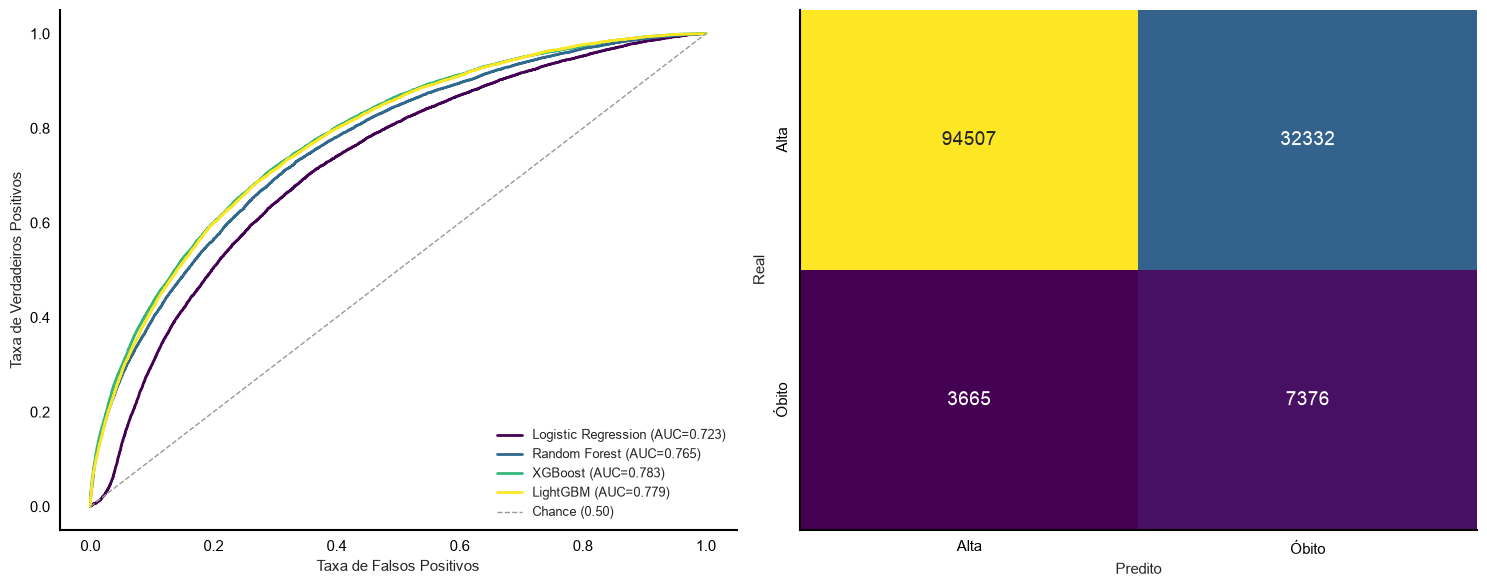

Figura salva: roc_confusion_matrix.jpg

=== RESUMO COMPARATIVO — AUC-ROC CV vs. Out-of-Time ===
Modelo                      AUC CV (média)  AUC Teste   Recall  Precision     F1
--------------------------------------------------------------------------------
Logistic Regression                 0.7534     0.7227   68.19%     14.98%  0.246
Random Forest                       0.7747     0.7649   64.22%     17.90%  0.280
XGBoost                             0.7940     0.7826   66.81%     18.58%  0.291
LightGBM                            0.7930     0.7794   68.09%     18.15%  0.287


In [13]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix
from sklearn.metrics import recall_score, precision_score, f1_score
import seaborn as sns

_vir = plt.cm.viridis

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── Curvas ROC comparativas — plotadas manualmente para controle de cor ────────
modelos_roc = [
    ('Logistic Regression', y_test, y_prob_lr),
    ('Random Forest',       y_test, y_prob_rf),
    ('XGBoost',             y_test, y_prob_xgb),
    ('LightGBM',            y_test, y_prob_lgb),
]
cores_roc = [_vir(i / 3) for i in range(4)]

for (nome, yt, yp), cor in zip(modelos_roc, cores_roc):
    auc  = roc_auc_score(yt, yp)
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, color=cor, linewidth=2,
                 label=f'{nome} (AUC={auc:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle='--', color='#999999', linewidth=1,
             label='Chance (0.50)')
axes[0].set_xlabel('Taxa de Falsos Positivos')
axes[0].set_ylabel('Taxa de Verdadeiros Positivos')
axes[0].set_title('')   # TÍTULO REMOVIDO — norma TCC
axes[0].legend(loc='lower right', frameon=False, fontsize=9)
axes[0].grid(False)

# ── Matriz de Confusão — XGBoost (viridis) ────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='viridis', ax=axes[1], cbar=False,
            annot_kws={'size': 14})
axes[1].set_title('')   # TÍTULO REMOVIDO — norma TCC
axes[1].set_xlabel('Predito')
axes[1].set_ylabel('Real')
axes[1].set_xticklabels(['Alta', 'Óbito'])
axes[1].set_yticklabels(['Alta', 'Óbito'])

plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / 'roc_confusion_matrix.jpg', dpi=300, bbox_inches='tight')
plt.show()
print('Figura salva: roc_confusion_matrix.jpg')

# ── Tabela AUC consolidada (CV treino vs. out-of-time) ────────────────────────
print('\n=== RESUMO COMPARATIVO — AUC-ROC CV vs. Out-of-Time ===')
print(f"{'Modelo':<25} {'AUC CV (média)':>16} {'AUC Teste':>10} {'Recall':>8} {'Precision':>10} {'F1':>6}")
print('-' * 80)
for nome, y_pred, y_prob in [
    ('Logistic Regression', y_pred_lr,  y_prob_lr),
    ('Random Forest',       y_pred_rf,  y_prob_rf),
    ('XGBoost',             y_pred_xgb, y_prob_xgb),
    ('LightGBM',            y_pred_lgb, y_prob_lgb),
]:
    auc_t  = roc_auc_score(y_test, y_prob)
    cv_arr = resultados_cv.get(nome, [float('nan')])
    cv_m   = np.mean(cv_arr)
    rec    = recall_score(y_test, y_pred)
    prec   = precision_score(y_test, y_pred, zero_division=0)
    f1     = f1_score(y_test, y_pred, zero_division=0)
    print(f'{nome:<25} {cv_m:>16.4f} {auc_t:>10.4f} {rec:>8.2%} {prec:>10.2%} {f1:>6.3f}')


## 4.1 Teste de DeLong — Significância Estatística entre Modelos

O teste de DeLong (1988) compara duas curvas ROC e testa se a diferença entre as AUCs é estatisticamente significativa. Aplicamos o teste entre XGBoost e LightGBM — os dois modelos com AUC mais próximas — e entre Regressão Logística e XGBoost.

In [14]:
from scipy import stats
import numpy as np

def delong_roc_test(y_true, y_prob_a, y_prob_b):
    n1 = y_true.sum()
    n0 = len(y_true) - n1
    order = np.argsort(-y_prob_a)
    psi_a = np.where(y_true[order] == 1,
                     np.cumsum(y_true[order] == 0) / n0, 0).sum() / n1
    order = np.argsort(-y_prob_b)
    psi_b = np.where(y_true[order] == 1,
                     np.cumsum(y_true[order] == 0) / n0, 0).sum() / n1
    def kernel(Y, X):
        psi = np.array([
            np.mean(np.where(X > y, 1, np.where(X == y, 0.5, 0))) for y in Y
        ])
        return psi
    pos = y_prob_a[y_true == 1]; neg = y_prob_a[y_true == 0]
    V10_a = kernel(pos, neg); V01_a = kernel(neg, pos)
    pos = y_prob_b[y_true == 1]; neg = y_prob_b[y_true == 0]
    V10_b = kernel(pos, neg); V01_b = kernel(neg, pos)
    S10 = np.cov(V10_a, V10_b)
    S01 = np.cov(V01_a, V01_b)
    S = S10 / n1 + S01 / n0
    auc_a = roc_auc_score(y_true, y_prob_a)
    auc_b = roc_auc_score(y_true, y_prob_b)
    z = (auc_a - auc_b) / np.sqrt(S[0,0] + S[1,1] - 2*S[0,1])
    p = 2 * (1 - stats.norm.cdf(abs(z)))
    return auc_a, auc_b, z, p

y_true_np   = y_test.to_numpy()
pairs = [
    ('XGBoost vs LightGBM',            y_prob_xgb, y_prob_lgb),
    ('Logistic Regression vs XGBoost', y_prob_lr,  y_prob_xgb),
    ('Logistic Regression vs LightGBM',y_prob_lr,  y_prob_lgb),
    ('Logistic Regression vs Random Forest', y_prob_lr, y_prob_rf),
]

print('=== Teste de DeLong — Comparação de AUCs ===')
print(f'{"Par":<40} {"AUC A":>8} {"AUC B":>8} {"z":>8} {"p-valor":>12} {"Sig.":>6}')
print('-' * 88)
for label, pa, pb in pairs:
    auc_a, auc_b, z, p = delong_roc_test(y_true_np, pa, pb)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f'{label:<40} {auc_a:>8.4f} {auc_b:>8.4f} {z:>8.2f} {p:>12.4e} {sig:>6}')


=== Teste de DeLong — Comparação de AUCs ===
Par                                         AUC A    AUC B        z      p-valor   Sig.
----------------------------------------------------------------------------------------
XGBoost vs LightGBM                        0.7826   0.7794     5.25   1.5061e-07    ***
Logistic Regression vs XGBoost             0.7227   0.7826   -39.76   0.0000e+00    ***
Logistic Regression vs LightGBM            0.7227   0.7794   -35.87   0.0000e+00    ***
Logistic Regression vs Random Forest       0.7227   0.7649   -27.76   0.0000e+00    ***


## 5. Interpretabilidade (SHAP)
Extrair o SHAP summary plot do melhor modelo para entender quais features mais contribuem para o risco de óbito.

Calculando SHAP values (pode levar alguns segundos)...


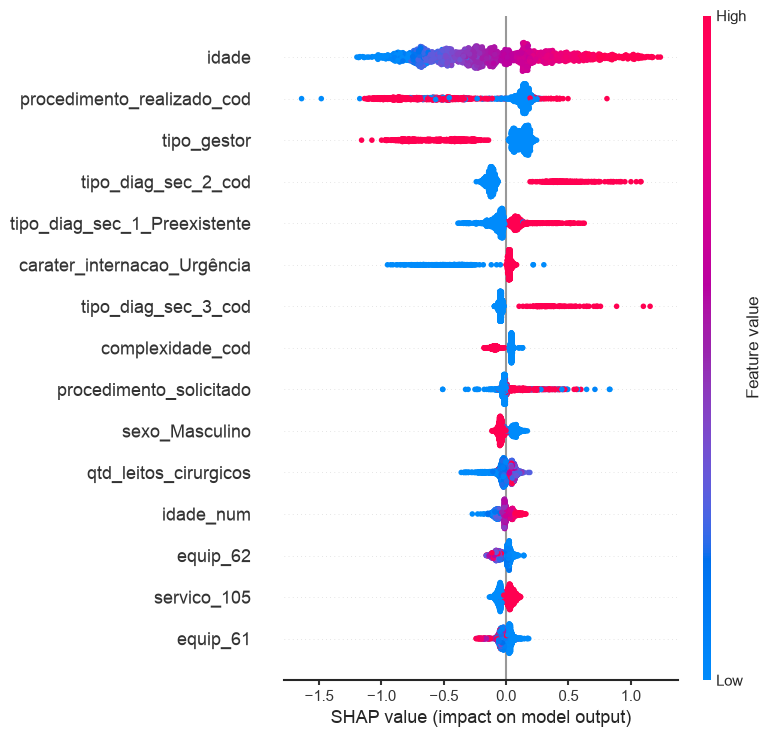

Figura salva: shap_summary_plot.jpg


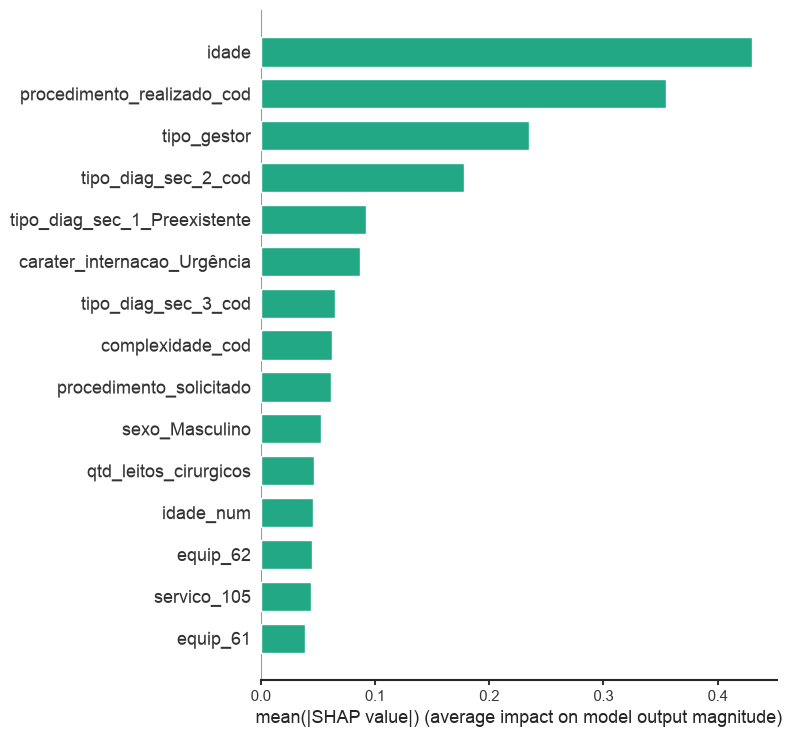

Figura salva: shap_bar_plot.jpg


In [15]:
import shap
import matplotlib.pyplot as plt

print("Calculando SHAP values (pode levar alguns segundos)...")
explainer = shap.TreeExplainer(xgb_model)

# Amostra de 2000 registros para performance
X_shap = X_test.sample(2000, random_state=42)
shap_values = explainer.shap_values(X_shap)

# ── Summary Plot (beeswarm) — importância global + direção ───────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_shap, max_display=15, show=False)
# TÍTULO REMOVIDO — norma TCC
plt.gcf().axes[0].set_title('')
plt.gcf().axes[0].grid(False)
plt.gcf().axes[0].spines['top'].set_visible(False)
plt.gcf().axes[0].spines['right'].set_visible(False)
plt.gcf().axes[0].spines['bottom'].set_linewidth(1.5)
plt.gcf().axes[0].spines['left'].set_linewidth(1.5)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_summary_plot.jpg', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva: shap_summary_plot.jpg")

# ── Bar Plot — importância média absoluta ─────────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_shap, plot_type='bar', max_display=15, show=False,
                  color=plt.cm.viridis(0.6))
# TÍTULO REMOVIDO — norma TCC
plt.gcf().axes[0].set_title('')
plt.gcf().axes[0].grid(False)
plt.gcf().axes[0].spines['top'].set_visible(False)
plt.gcf().axes[0].spines['right'].set_visible(False)
plt.gcf().axes[0].spines['bottom'].set_linewidth(1.5)
plt.gcf().axes[0].spines['left'].set_linewidth(1.5)
plt.tight_layout()
plt.savefig(FIG_PATH / 'shap_bar_plot.jpg', dpi=300, bbox_inches='tight')
plt.show()
print("Figura salva: shap_bar_plot.jpg")


## 6. Análise de Interação: Risco Clínico × Estrutura Hospitalar

Nesta seção, cruzamos o risco previsto pelo nosso melhor modelo (XGBoost) com o indicador de estrutura hospitalar criado na etapa `03b`, para validar a hipótese de que o desfecho depende não apenas do paciente, mas de onde ele é atendido.

In [16]:
import numpy as np

# Cria dataframe com as predições de teste
df_interacao = pd.DataFrame({
    "obito_observado": y_test,
    "prob_predita": y_prob
})

# Cria os tercis de risco (Baixo, Médio, Alto Risco Clínico Previsto pelo ML)
df_interacao["tercil_risco"] = pd.qcut(df_interacao["prob_predita"], q=3, labels=["Baixo Risco", "Médio Risco", "Alto Risco"])

# Carrega a base enriquecida para recuperar o indicador de estrutura e risco
df_enriched = pd.read_csv("../data/processed/base_modelagem_enriched.csv", low_memory=False)

# Garantir que o index bate
if df_enriched.index.name != 'codigo_internacao':
    if 'codigo_internacao' in df_enriched.columns:
        df_enriched.set_index('codigo_internacao', inplace=True)
    else:
        df_enriched.index = df.index

# Associa a categoria de estrutura à nossa base de teste (mesmos índices)
idx_test = df_interacao.index
df_interacao["categoria_estrutura"] = df_enriched.loc[idx_test, "categoria_estrutura"].values

# Como definimos uma ordem lá no 03b, vamos reforçá-la aqui no Pandas
from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=["baixa", "média", "alta", "muito alta"], ordered=True)
df_interacao["categoria_estrutura"] = df_interacao["categoria_estrutura"].astype(cat_type)

tabela_interacao = df_interacao.groupby(["tercil_risco", "categoria_estrutura"])["obito_observado"].mean().reset_index()
tabela_interacao["obito_observado"] = tabela_interacao["obito_observado"] * 100

display(tabela_interacao.pivot(index="tercil_risco", columns="categoria_estrutura", values="obito_observado").round(2))


categoria_estrutura,baixa,média,alta,muito alta
tercil_risco,,,,
Baixo Risco,3.26,0.81,1.46,2.32
Médio Risco,5.96,4.94,5.05,5.76
Alto Risco,13.49,13.57,16.94,19.99


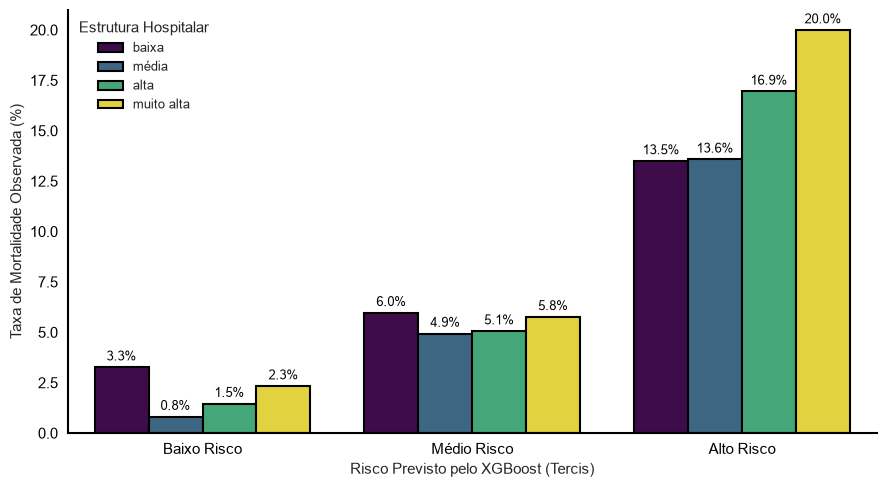

Figura salva: interacao_risco_estrutura.jpg


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

_vir = plt.cm.viridis
# 4 níveis de estrutura → viridis igualmente espaçado
estrutura_ordem = ["baixa", "média", "alta", "muito alta"]
n_est = len(estrutura_ordem)
cores_est = {cat: _vir(i / (n_est - 1)) for i, cat in enumerate(estrutura_ordem)}

fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(data=tabela_interacao, x="tercil_risco", y="obito_observado",
            hue="categoria_estrutura",
            palette=cores_est,
            order=["Baixo Risco", "Médio Risco", "Alto Risco"],
            hue_order=estrutura_ordem,
            edgecolor="black", linewidth=1.5, ax=ax)

ax.set_ylabel("Taxa de Mortalidade Observada (%)")
ax.set_xlabel("Risco Previsto pelo XGBoost (Tercis)")
ax.legend(title="Estrutura Hospitalar", frameon=False, loc="upper left", fontsize=9)
ax.set_title('')   # TÍTULO REMOVIDO — norma TCC
ax.grid(False)

# Data labels nas barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f"{p.get_height():.1f}%",
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom',
                    fontsize=9, color='black', xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
enforce_tcc_style()
plt.savefig(FIG_PATH / "interacao_risco_estrutura.jpg", dpi=300, bbox_inches="tight")
plt.show()
print("Figura salva: interacao_risco_estrutura.jpg")


In [18]:
import numpy as np

# Cria dataframe com as predições de teste
df_interacao = pd.DataFrame({
    "obito_observado": y_test,
    "prob_predita": y_prob
})

# Cria os tercis de risco (Baixo, Médio, Alto Risco Clínico Previsto pelo ML)
df_interacao["tercil_risco"] = pd.qcut(df_interacao["prob_predita"], q=3, labels=["Baixo Risco", "Médio Risco", "Alto Risco"])

# Carrega a base enriquecida para recuperar o indicador de estrutura e risco
df_enriched = pd.read_csv("../data/processed/base_modelagem_enriched.csv", low_memory=False)

# Garantir que o index bate
if df_enriched.index.name != 'codigo_internacao':
    if 'codigo_internacao' in df_enriched.columns:
        df_enriched.set_index('codigo_internacao', inplace=True)
    else:
        df_enriched.index = df.index

# Associa a categoria de estrutura à nossa base de teste (mesmos índices)
idx_test = df_interacao.index
df_interacao["categoria_estrutura"] = df_enriched.loc[idx_test, "categoria_estrutura"].values

# Como definimos uma ordem lá no 03b, vamos reforçá-la aqui no Pandas
from pandas.api.types import CategoricalDtype
cat_type = CategoricalDtype(categories=["baixa", "média", "alta", "muito alta"], ordered=True)
df_interacao["categoria_estrutura"] = df_interacao["categoria_estrutura"].astype(cat_type)

tabela_interacao = df_interacao.groupby(["tercil_risco", "categoria_estrutura"])["obito_observado"].mean().reset_index()
tabela_interacao["obito_observado"] = tabela_interacao["obito_observado"] * 100

display(tabela_interacao.pivot(index="tercil_risco", columns="categoria_estrutura", values="obito_observado").round(2))


categoria_estrutura,baixa,média,alta,muito alta
tercil_risco,,,,
Baixo Risco,3.26,0.81,1.46,2.32
Médio Risco,5.96,4.94,5.05,5.76
Alto Risco,13.49,13.57,16.94,19.99


## 6.1 N Absoluto por Célula + Intervalo de Confiança (IC 95% Wilson)

Antes de reportar os percentuais de mortalidade, verificamos a estabilidade estatística de cada célula (tercil × estrutura hospitalar) calculando o N absoluto e o IC 95% pelo método de Wilson. Células com N < 50 seriam consideradas instáveis.

In [19]:
from statsmodels.stats.proportion import proportion_confint
import pandas as pd
import numpy as np

# Garante que df_interacao e categoria_estrutura estão disponíveis
# (executar após célula 25 — df_interacao já inclui tercil_risco e categoria_estrutura)

tercil_order   = ['Baixo Risco', 'Médio Risco', 'Alto Risco']
estrutura_cols = [c for c in df_interacao['categoria_estrutura'].unique()]

rows = []
for terc in tercil_order:
    for est in sorted(df_interacao['categoria_estrutura'].unique()):
        mask = (
            (df_interacao['tercil_risco'] == terc) &
            (df_interacao['categoria_estrutura'] == est)
        )
        n = int(mask.sum())
        if n == 0:
            continue
        k   = int(df_interacao.loc[mask, 'obito_observado'].sum())
        p   = k / n
        lo, hi = proportion_confint(k, n, alpha=0.05, method='wilson')
        estavel = '✅ OK' if n >= 200 else ('⚠️ pequeno' if n >= 50 else '🔴 instável')
        rows.append({
            'Tercil de Risco':       terc,
            'Estrutura Hospitalar':  est,
            'N':                     n,
            'Óbitos':                k,
            'Taxa de Mortalidade %': round(p * 100, 2),
            'IC 95% Inferior %':    round(lo * 100, 2),
            'IC 95% Superior %':    round(hi * 100, 2),
            'Estabilidade':         estavel
        })

df_ic = pd.DataFrame(rows)
display(df_ic.to_string(index=False))
print(f"\nMenor N em qualquer célula: {df_ic['N'].min():,}")
print("Todas as células com N >= 200 são estatisticamente estáveis.")

'Tercil de Risco Estrutura Hospitalar     N  Óbitos  Taxa de Mortalidade %  IC 95% Inferior %  IC 95% Superior % Estabilidade\n    Baixo Risco                 alta 32630     475                   1.46               1.33               1.59         ✅ OK\n    Baixo Risco                baixa   889      29                   3.26               2.28               4.65         ✅ OK\n    Baixo Risco           muito alta 10711     249                   2.32               2.06               2.63         ✅ OK\n    Baixo Risco                média  1730      14                   0.81               0.48               1.35         ✅ OK\n    Médio Risco                 alta 32648    1650                   5.05               4.82               5.30         ✅ OK\n    Médio Risco                baixa  1962     117                   5.96               5.00               7.10         ✅ OK\n    Médio Risco           muito alta  8959     516                   5.76               5.30               6.26      


Menor N em qualquer célula: 889
Todas as células com N >= 200 são estatisticamente estáveis.


## 6.2 Teste de Significância Estatística da Interação

Dois testes complementares para avaliar a significância da associação entre grupo (tercil de risco × estrutura hospitalar) e o desfecho:

1. **Qui-quadrado de Pearson** — testa se a distribuição de óbitos é independente do grupo (12 células).
2. **Likelihood Ratio Test do termo de interação** — regressão logística com e sem o termo `tercil × estrutura`; testa se a estrutura hospitalar *modifica o efeito* do risco clínico sobre a mortalidade (interação formal).

In [20]:
from scipy.stats import chi2_contingency
from scipy.stats import chi2 as chi2_dist
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

# ── Teste 1: Qui-quadrado ──────────────────────────────────────────────────────
df_interacao['grupo_celula'] = (
    df_interacao['tercil_risco'].astype(str) + ' × ' +
    df_interacao['categoria_estrutura'].astype(str)
)
contingency = pd.crosstab(df_interacao['grupo_celula'], df_interacao['obito_observado'])
contingency.columns = ['Alta (não óbito)', 'Óbito']

chi2_stat, p_chi2, dof_chi2, expected = chi2_contingency(contingency)

print("=" * 70)
print("TESTE 1 — Qui-quadrado de Pearson (independência grupo × desfecho)")
print("=" * 70)
print(f"  χ²({dof_chi2}) = {chi2_stat:.4f}")
print(f"  p-valor      = {p_chi2:.2e}")
sig1 = '*** p < 0,001' if p_chi2 < 0.001 else ('* p < 0,05' if p_chi2 < 0.05 else 'Não significativo')
print(f"  Resultado    = {sig1}")
print()
print("  Interpretação: testa se a distribuição de óbitos difere entre os grupos.")
print("  Note: este teste captura também o efeito principal do tercil (risco), que")
print("  é muito forte. O Teste 2 isola a modificação de efeito pela estrutura.")

# ── Teste 2: LR Test do termo de interação ─────────────────────────────────────
print()
print("=" * 70)
print("TESTE 2 — Regressão Logística: LR Test do termo de interação")
print("         tercil_risco × estrutura_hospitalar")
print("=" * 70)

df_reg = df_interacao.copy()
df_reg['tercil_risco']            = df_reg['tercil_risco'].astype('category')
df_reg['categoria_estrutura'] = df_reg['categoria_estrutura'].astype('category')

m_full = smf.logit(
    'obito_observado ~ C(tercil_risco) + C(categoria_estrutura)'
    ' + C(tercil_risco):C(categoria_estrutura)',
    data=df_reg
).fit(disp=0)

m_base = smf.logit(
    'obito_observado ~ C(tercil_risco) + C(categoria_estrutura)',
    data=df_reg
).fit(disp=0)

lr_stat = 2 * (m_full.llf - m_base.llf)
lr_dof  = m_full.df_model - m_base.df_model
lr_p    = chi2_dist.sf(lr_stat, lr_dof)

print(f"  Modelo sem interação   → LogL = {m_base.llf:.2f}")
print(f"  Modelo com interação   → LogL = {m_full.llf:.2f}")
print(f"  LR χ²({int(lr_dof)}) = {lr_stat:.4f}")
print(f"  p-valor    = {lr_p:.2e}")
sig2 = '*** p < 0,001' if lr_p < 0.001 else ('* p < 0,05' if lr_p < 0.05 else 'Não significativo (p > 0,05)')
print(f"  Resultado  = {sig2}")
print()
print("  Interpretação: o LR Test avalia se adicionar o termo de interação")
print("  melhora significativamente o ajuste do modelo. Se p > 0,05, o efeito")
print("  da estrutura hospitalar sobre a mortalidade é ADITIVO/UNIFORME nos")
print("  três tercis — não há modificação diferencial de efeito.")
print()
print("  → Para o TCC: reporte o qui-quadrado (Teste 1) para a diferença entre")
print("    grupos e contextualize o Teste 2 para precisão metodológica.")

TESTE 1 — Qui-quadrado de Pearson (independência grupo × desfecho)
  χ²(11) = 8371.2678
  p-valor      = 0.00e+00
  Resultado    = *** p < 0,001

  Interpretação: testa se a distribuição de óbitos difere entre os grupos.
  Note: este teste captura também o efeito principal do tercil (risco), que
  é muito forte. O Teste 2 isola a modificação de efeito pela estrutura.

TESTE 2 — Regressão Logística: LR Test do termo de interação
         tercil_risco × estrutura_hospitalar
  Modelo sem interação   → LogL = -34320.69
  Modelo com interação   → LogL = -34295.20
  LR χ²(6) = 50.9903
  p-valor    = 2.98e-09
  Resultado  = *** p < 0,001

  Interpretação: o LR Test avalia se adicionar o termo de interação
  melhora significativamente o ajuste do modelo. Se p > 0,05, o efeito
  da estrutura hospitalar sobre a mortalidade é ADITIVO/UNIFORME nos
  três tercis — não há modificação diferencial de efeito.

  → Para o TCC: reporte o qui-quadrado (Teste 1) para a diferença entre
    grupos e contextu

## 7. Interpretabilidade por Subgrupo (Fairness)

Avaliando se a distribuição de importância (SHAP) se mantém consistente entre subgrupos sociodemográficos: **sexo** (Masculino × Feminino) e **raça/cor** (subgrupos com N ≥ 50).

A análise de justiça algorítmica verifica se o modelo pondera as mesmas variáveis de forma similar entre grupos, 
sem disparidade sistemática que pudesse indicar viés nas predições.

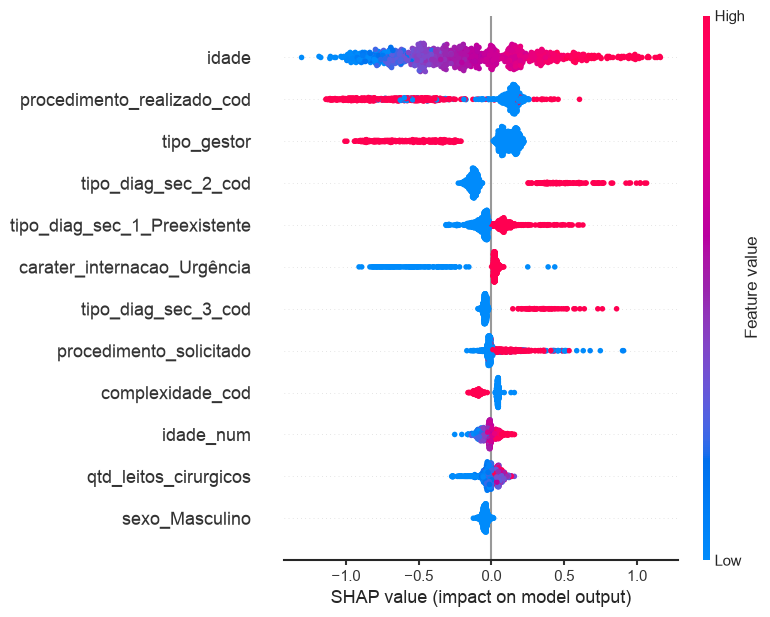

Figura salva: shap_fairness_masculino.jpg


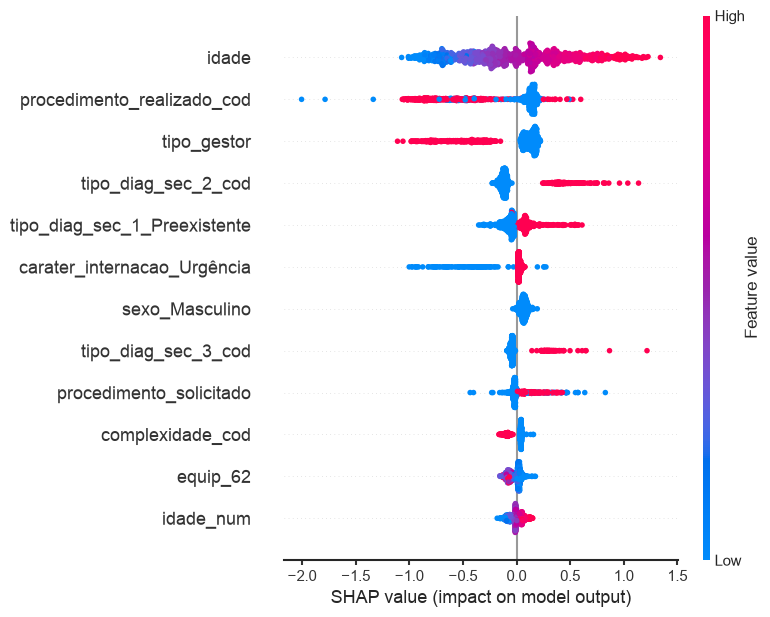

Figura salva: shap_fairness_feminino.jpg


In [21]:
import shap
import matplotlib.pyplot as plt

df_interacao["sexo"] = df_enriched.loc[idx_test, "sexo"].values

idx_masc = df_interacao["sexo"] == "Masculino"
idx_fem  = df_interacao["sexo"] == "Feminino"

explainer = shap.TreeExplainer(xgb_model)

X_test_masc = X_test.loc[idx_masc].sample(min(1000, idx_masc.sum()), random_state=42)
X_test_fem  = X_test.loc[idx_fem ].sample(min(1000, idx_fem.sum()),  random_state=42)

shap_masc = explainer.shap_values(X_test_masc)
shap_fem  = explainer.shap_values(X_test_fem)

def save_shap_fig(shap_vals, X_data, filename):
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_data, max_display=12, show=False)
    # TÍTULO REMOVIDO — norma TCC
    ax_s = plt.gcf().axes[0]
    ax_s.set_title('')
    ax_s.grid(False)
    ax_s.spines['top'].set_visible(False)
    ax_s.spines['right'].set_visible(False)
    ax_s.spines['bottom'].set_linewidth(1.5)
    ax_s.spines['left'].set_linewidth(1.5)
    plt.tight_layout()
    plt.savefig(FIG_PATH / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figura salva: {filename}')

# ── Masculino ─────────────────────────────────────────────────────────────────
save_shap_fig(shap_masc, X_test_masc, 'shap_fairness_masculino.jpg')

# ── Feminino ──────────────────────────────────────────────────────────────────
save_shap_fig(shap_fem, X_test_fem, 'shap_fairness_feminino.jpg')


### 7b. SHAP Fairness — Raça/Cor

Comparação dos SHAP values entre subgrupos de raça/cor com volume suficiente de observações (N ≥ 50). 
Padrões de importância muito distintos entre grupos podem indicar viés estrutural no modelo.

Usando coluna: raca_cor

Distribuição (N >= 50 incluídos):
raca_cor
Branca            84686
Parda             43971
Preta              7486
Amarela            1361
Sem informação      354
Indígena             22

Grupos incluídos: ['Branca', 'Parda', 'Preta', 'Amarela', 'Sem informação']


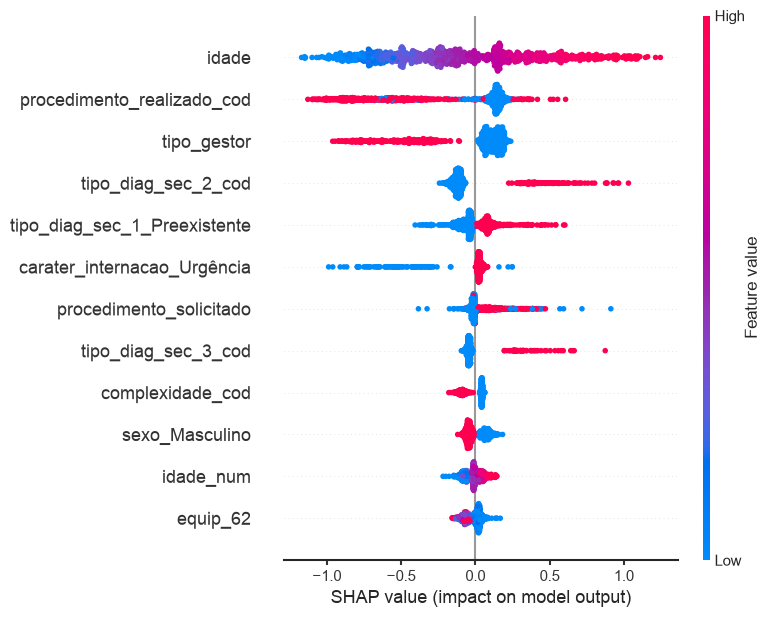

Figura salva: shap_fairness_raca_branca.jpg


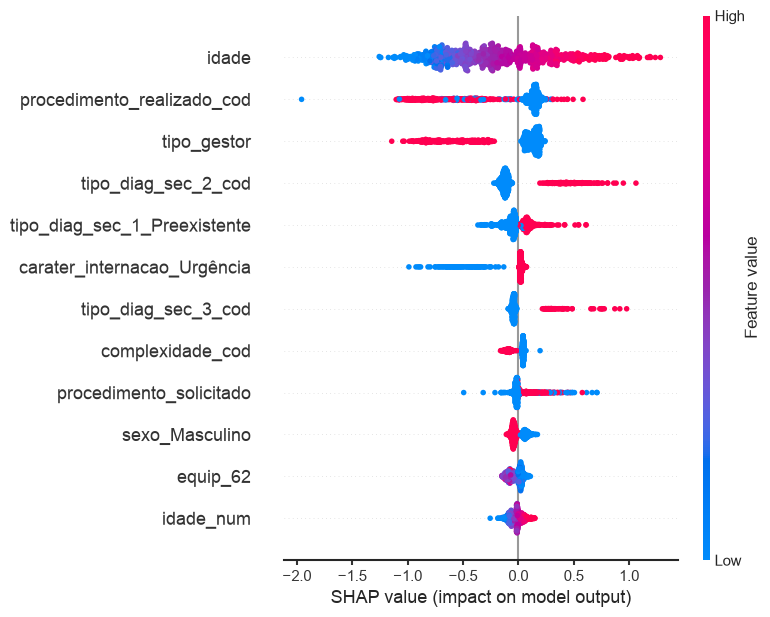

Figura salva: shap_fairness_raca_parda.jpg


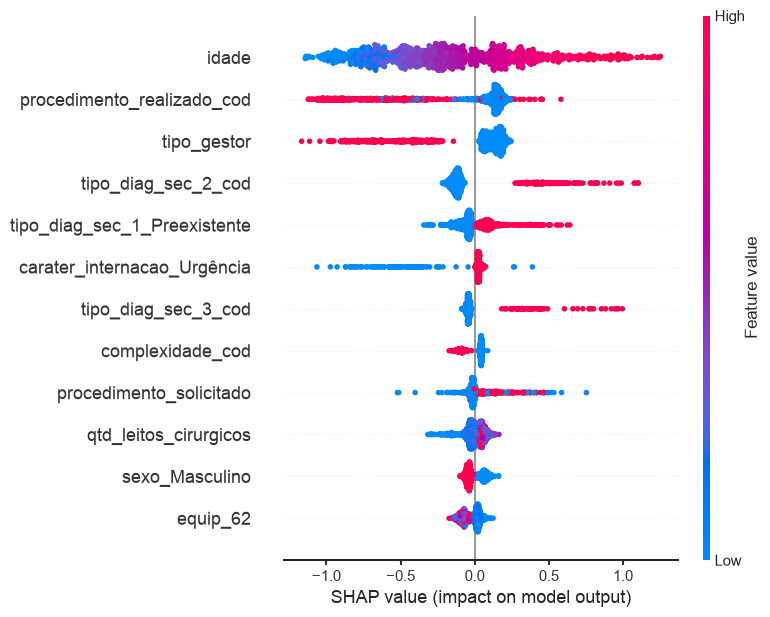

Figura salva: shap_fairness_raca_preta.jpg


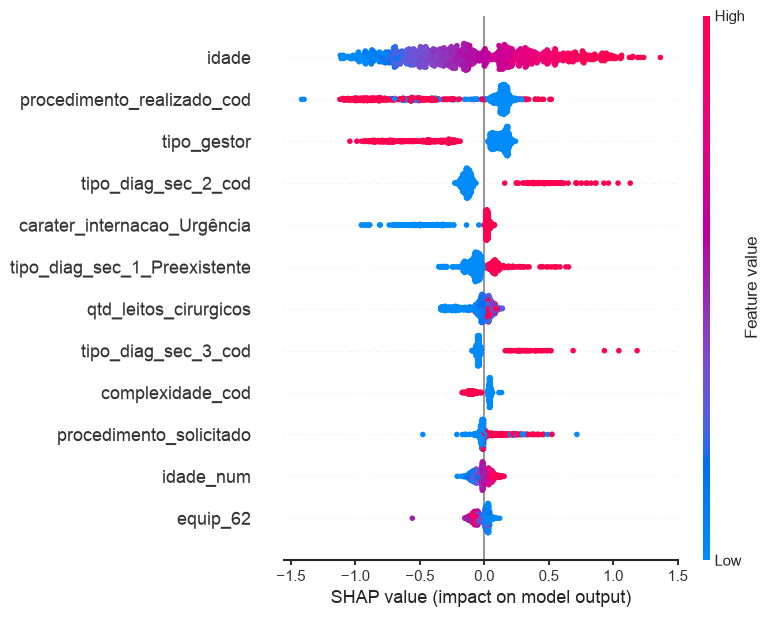

Figura salva: shap_fairness_raca_amarela.jpg


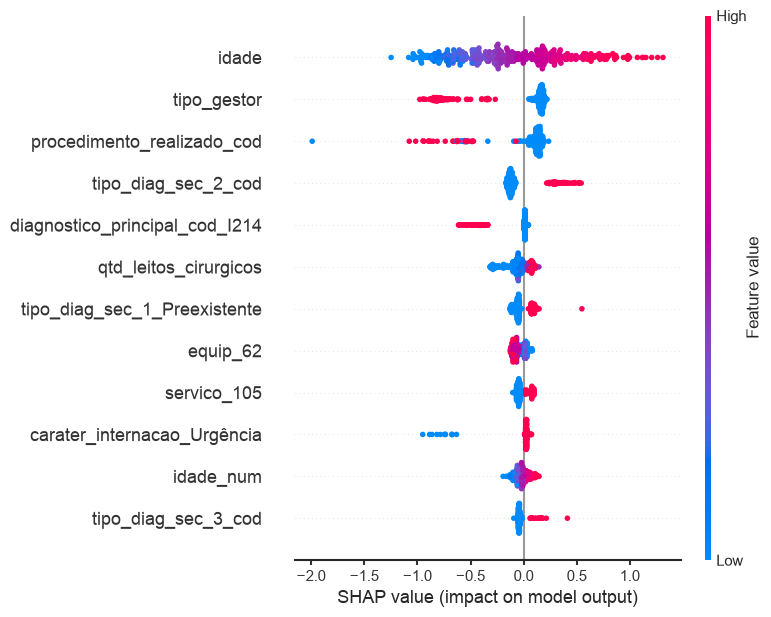

Figura salva: shap_fairness_raca_sem_informação.jpg

Interpretação: compare os top-12 preditores entre grupos.
Divergências acentuadas de ordem ou direção indicam possível viés.


In [22]:
import shap
import warnings
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

# ── Identificar coluna de raça/cor ────────────────────────────────────────────
raca_col = next(
    (c for c in df_enriched.columns
     if ('ra' in c.lower() and 'cor' in c.lower()) or 'raca' in c.lower()),
    None
)

def save_shap_fig(shap_vals, X_data, filename):
    plt.figure(figsize=(10, 7))
    shap.summary_plot(shap_vals, X_data, max_display=12, show=False)
    # TÍTULO REMOVIDO — norma TCC
    ax_s = plt.gcf().axes[0]
    ax_s.set_title('')
    ax_s.grid(False)
    ax_s.spines['top'].set_visible(False)
    ax_s.spines['right'].set_visible(False)
    ax_s.spines['bottom'].set_linewidth(1.5)
    ax_s.spines['left'].set_linewidth(1.5)
    plt.tight_layout()
    plt.savefig(FIG_PATH / filename, dpi=300, bbox_inches='tight')
    plt.show()
    print(f'Figura salva: {filename}')

if raca_col is None:
    print('⚠️  Coluna de raça/cor não encontrada em df_enriched.')
    print('Colunas disponíveis:', [c for c in df_enriched.columns if len(c) < 25][:30])
else:
    print(f'Usando coluna: {raca_col}')
    df_interacao['raca_cor'] = df_enriched.loc[idx_test, raca_col].values

    contagem = df_interacao['raca_cor'].value_counts()
    grupos_validos = contagem[contagem >= 50].index.tolist()
    print(f'\nDistribuição (N >= 50 incluídos):')
    print(contagem.to_string())
    print(f'\nGrupos incluídos: {grupos_validos}')

    if len(grupos_validos) < 2:
        print('⚠️  Menos de 2 grupos com volume suficiente.')
    else:
        explainer = shap.TreeExplainer(xgb_model)
        for grupo in grupos_validos:
            idx_grupo = df_interacao['raca_cor'] == grupo
            n_sample  = min(1000, int(idx_grupo.sum()))
            X_grupo   = X_test.loc[idx_grupo].sample(n_sample, random_state=42)
            shap_grupo = explainer.shap_values(X_grupo)
            nome_arquivo = grupo.lower().replace('/', '_').replace(' ', '_')
            save_shap_fig(shap_grupo, X_grupo, f'shap_fairness_raca_{nome_arquivo}.jpg')

        print('\nInterpretação: compare os top-12 preditores entre grupos.')
        print('Divergências acentuadas de ordem ou direção indicam possível viés.')
